Libraries imported successfully!
Dataset loaded successfully!
Dataset Shape:
(1000, 7)

Column Names:
['distance_km', 'warehouse_load', 'order_hour', 'items_count', 'weather_risk', 'carrier_delay_rate', 'target']
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   distance_km         1000 non-null   float64
 1   warehouse_load      1000 non-null   int64  
 2   order_hour          1000 non-null   int64  
 3   items_count         1000 non-null   int64  
 4   weather_risk        1000 non-null   int64  
 5   carrier_delay_rate  1000 non-null   float64
 6   target              1000 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 54.8 KB
Missing Values:
distance_km           0
warehouse_load        0
order_hour            0
items_count           0
weather_risk          0
carrier_delay_rate    0
target   

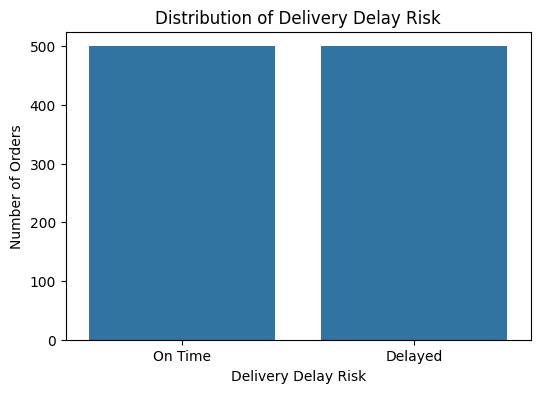

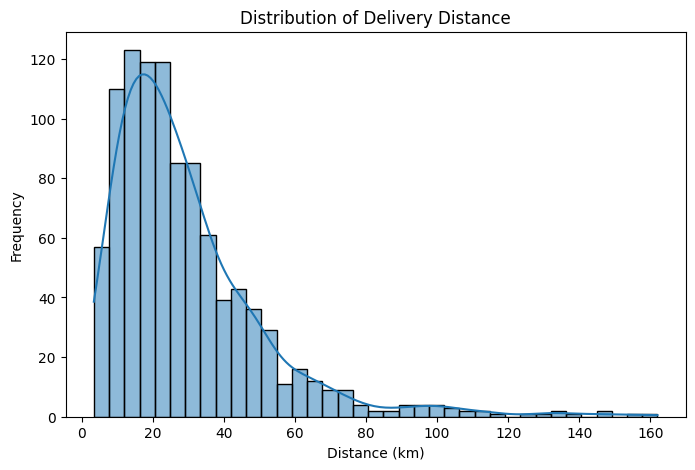

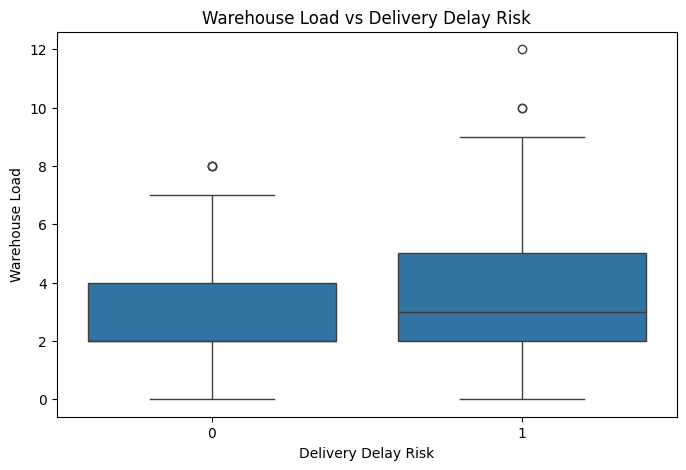

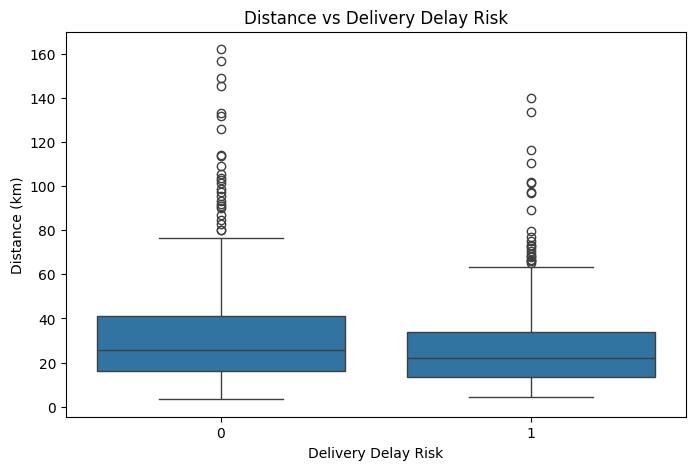

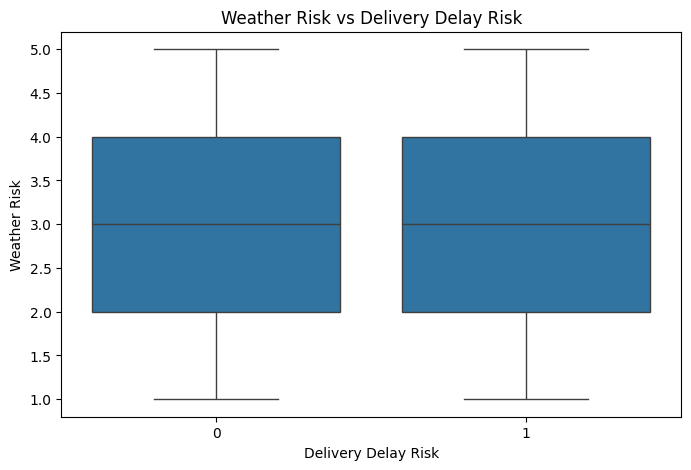

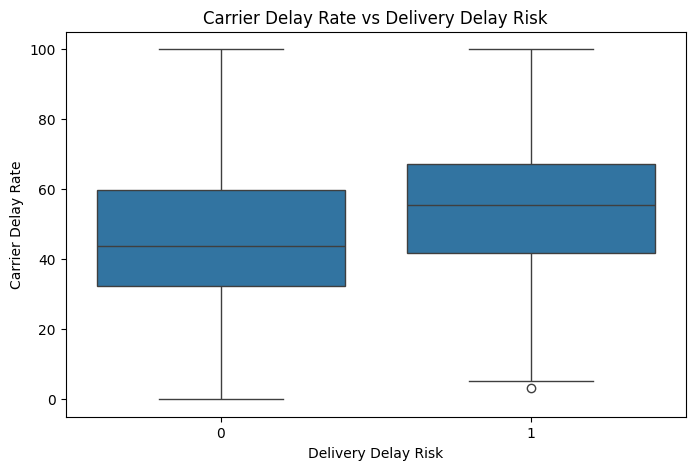

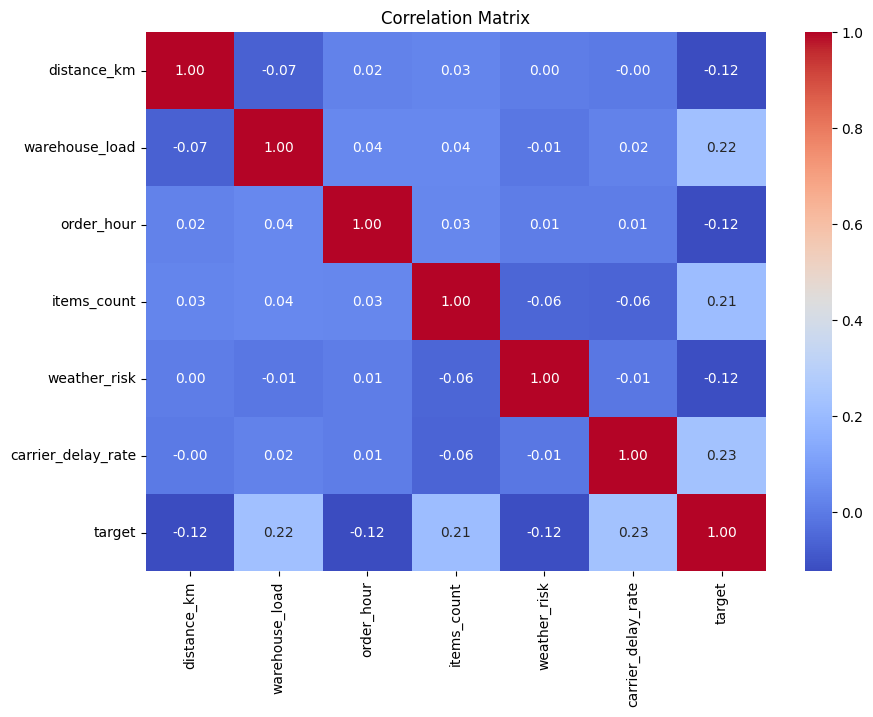

Features:
['distance_km', 'warehouse_load', 'order_hour', 'items_count', 'weather_risk', 'carrier_delay_rate']

Target:
target
Training Set Shape: (800, 6)
Testing Set Shape: (200, 6)
Feature scaling completed!
Model training completed!
Predictions generated successfully!
FINAL MODEL PERFORMANCE
Accuracy  : 0.6250
Precision : 0.6126
Recall    : 0.6800
F1-Score  : 0.6445
ROC-AUC   : 0.7146
CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.64      0.57      0.60       100
           1       0.61      0.68      0.64       100

    accuracy                           0.62       200
   macro avg       0.63      0.62      0.62       200
weighted avg       0.63      0.62      0.62       200

Confusion Matrix:
[[57 43]
 [32 68]]

True Negative : 57
False Positive: 43
False Negative: 32
True Positive : 68


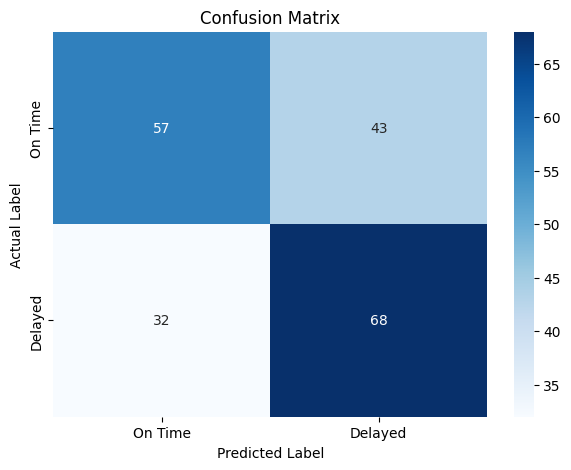

<Figure size 700x500 with 0 Axes>

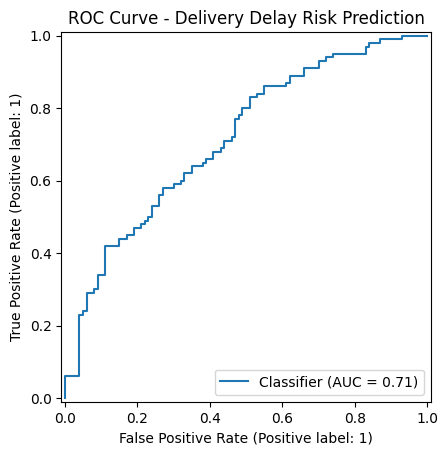

LOGISTIC REGRESSION COEFFICIENTS


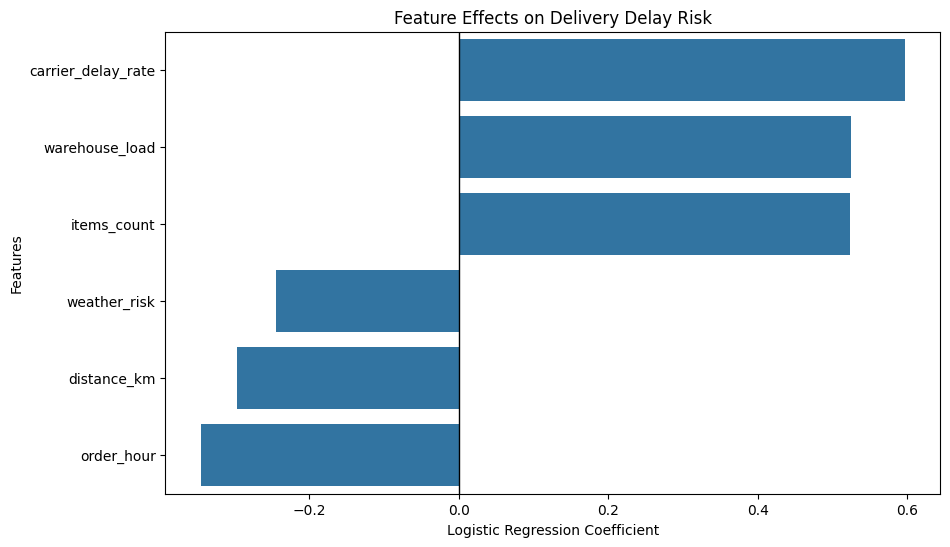

,Actual,Predicted,Probability_of_Delay
0,1,1,0.550232
1,0,0,0.173347
2,0,0,0.132403
3,0,0,0.096800
4,1,1,0.731756
5,1,1,0.711607
6,1,1,0.798188
7,1,1,0.804766
8,0,1,0.729209
9,0,1,0.579745


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

print("Libraries imported successfully!")


df = pd.read_csv("dataset_09_delivery_delay_risk.csv")

print("Dataset loaded successfully!")


df.head()



print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())


print("Dataset Information:")
df.info()


df.describe()



print("Missing Values:")
print(df.isnull().sum())

print("Duplicate Rows:")
print(df.duplicated().sum())


print("Target Distribution:")
print(df["target"].value_counts())

print("\nTarget Percentage:")
print(df["target"].value_counts(normalize=True) * 100)


plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="target")

plt.title("Distribution of Delivery Delay Risk")
plt.xlabel("Delivery Delay Risk")
plt.ylabel("Number of Orders")

plt.xticks([0, 1], ["On Time", "Delayed"])

plt.show()


plt.figure(figsize=(8, 5))

sns.histplot(df["distance_km"], kde=True)

plt.title("Distribution of Delivery Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Frequency")

plt.show()


plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="target", y="warehouse_load")

plt.title("Warehouse Load vs Delivery Delay Risk")
plt.xlabel("Delivery Delay Risk")
plt.ylabel("Warehouse Load")

plt.show()


plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="target", y="distance_km")

plt.title("Distance vs Delivery Delay Risk")
plt.xlabel("Delivery Delay Risk")
plt.ylabel("Distance (km)")

plt.show()


plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="target", y="weather_risk")

plt.title("Weather Risk vs Delivery Delay Risk")
plt.xlabel("Delivery Delay Risk")
plt.ylabel("Weather Risk")

plt.show()


plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="target", y="carrier_delay_rate")

plt.title("Carrier Delay Rate vs Delivery Delay Risk")
plt.xlabel("Delivery Delay Risk")
plt.ylabel("Carrier Delay Rate")

plt.show()

plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()


X = df.drop("target", axis=1)

y = df["target"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")



model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

print("Model training completed!")



y_pred = model.predict(X_test_scaled)

y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully!")


accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

print("FINAL MODEL PERFORMANCE")
print("=" * 40)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")


print("CLASSIFICATION REPORT")
print("=" * 40)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTrue Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["On Time", "Delayed"],
    yticklabels=["On Time", "Delayed"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()


plt.figure(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve - Delivery Delay Risk Prediction")

plt.show()

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

print("LOGISTIC REGRESSION COEFFICIENTS")
print("=" * 45)

coefficients


plt.figure(figsize=(10, 6))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Feature Effects on Delivery Delay Risk")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Features")

plt.axvline(
    x=0,
    color="black",
    linewidth=1
)

plt.show()


results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability_of_Delay": y_prob
})

results.head(10)